# Histogram Equalisation and CLAHE: Code Walkthrough

We use a photo from the Outworld festival, a dark crowd lit by intense LED rigs.
This is a perfect test image because it has two very different brightness zones at the same time:
- A huge dark area (the crowd)
- A small but very bright area (the LED lights)

That mix causes problems for basic histogram equalisation, and we will see exactly why, and how CLAHE fixes it.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Load the Image

We load it in **grayscale**: black and white, no colour.
Every pixel is just a number from 0 (pure black) to 255 (pure white).


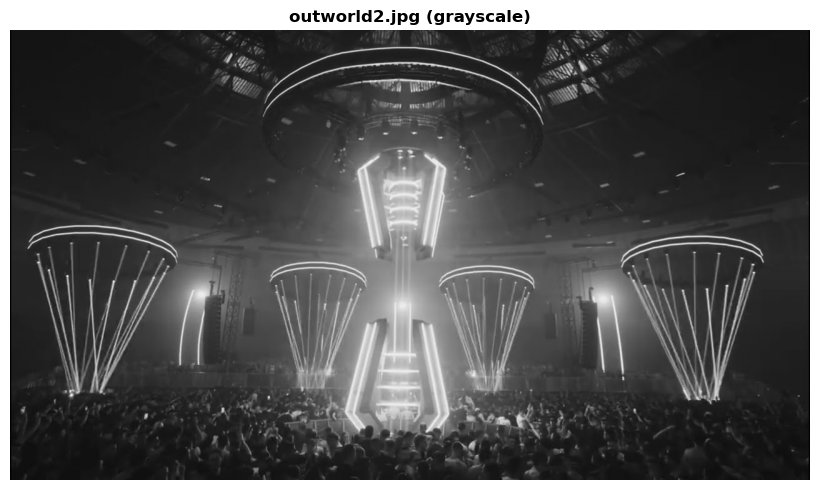

Image size  : 720 rows x 1280 columns = 921,600 pixels
Pixel range : 0 (darkest) to 254 (brightest)


In [6]:
img = cv2.imread('outworld2.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('outworld2.jpg (grayscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image size  : {img.shape[0]} rows x {img.shape[1]} columns = {img.size:,} pixels")
print(f"Pixel range : {img.min()} (darkest) to {img.max()} (brightest)")


## 2. The Histogram: What Brightness Does the Image Use?

A histogram is a bar chart of pixel counts.
Bar 0 = how many pixels are pure black. Bar 255 = how many are pure white.

A tall bar means a lot of pixels have that brightness.
A short bar (or no bar) means almost no pixels are that bright.

We expect to see a big pile on the left (dark crowd) and a smaller spike on the right (bright LEDs).


In [ ]:
# Count how many pixels have each brightness value (0 to 255)
hist = np.bincount(img.flatten(), minlength=256)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Input Image')
axes[0].axis('off')

axes[1].bar(range(256), hist, color='steelblue', width=1)
axes[1].set_title('Histogram: pixel count per brightness level')
axes[1].set_xlabel('Brightness (0 = black, 255 = white)')
axes[1].set_ylabel('Number of pixels')
axes[1].axvline(x=img.min(), color='red',   linestyle='--', linewidth=1.2, label=f'darkest = {img.min()}')
axes[1].axvline(x=img.max(), color='green', linestyle='--', linewidth=1.2, label=f'brightest = {img.max()}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. The CDF: Running Total of the Histogram

The **CDF** (Cumulative Distribution Function) answers one question for every brightness level:
> "What percentage of all pixels are this bright or darker?"

You build it in two steps:

Step 1: Turn counts into percentages:
`prob[r] = hist[r] / total_pixels`

Step 2: Add them up as you go from left to right:
`CDF[r] = prob[0] + prob[1] + ... + prob[r]`

The CDF always:
- Starts at (or near) 0 on the left
- Ends at exactly 1.0 on the right
- Never goes down, it can only stay flat or rise

Where the CDF shoots up steeply = lots of pixels at that brightness.
Where the CDF is flat = almost no pixels at that brightness.


In [ ]:
N    = img.size          # total number of pixels
prob = hist / N          # step 1: turn counts into fractions
cdf  = np.cumsum(prob)   # step 2: running total (cumulative sum)

# Quick check: should both be 1.0
print(f"prob adds up to : {prob.sum():.4f}  (should be 1.0)")
print(f"CDF at r=255    : {cdf[255]:.4f}  (should be 1.0)")
print()

# Print a few rows so you can see the pattern
print(f"{'Brightness':>12}  {'Count':>10}  {'% of pixels':>12}  {'CDF':>8}")
print("-" * 48)
for r in [0, 30, 60, 90, 120, 150, 180, 210, 240, 255]:
    print(f"{r:>12}  {hist[r]:>10}  {prob[r]*100:>11.2f}%  {cdf[r]:>8.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(256), prob, color='steelblue')
axes[0].set_title('Step 1: Percentage of pixels at each brightness')
axes[0].set_xlabel('Brightness')
axes[0].set_ylabel('Fraction of pixels')

axes[1].plot(range(256), cdf, color='darkorange', linewidth=2)
axes[1].set_title('Step 2: CDF (running total)')
axes[1].set_xlabel('Brightness')
axes[1].set_ylabel('Cumulative fraction')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50% of pixels are below this')
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Building the Remapping Table

Now we turn the CDF into a **lookup table**, a simple cheat sheet that says:
> "Old brightness X becomes new brightness Y."

The formula is:
```
new_brightness = round( 255 x CDF[old_brightness] )
```

The CDF rises steeply where there are lots of pixels. Multiplying by 255 and rounding
spreads those crowded pixels across a much wider brightness range.
Pixels that were all scrunched together in the dark zone get spread out from, say, 10 to 80.
That is what makes the image look more detailed and higher contrast.

We store this remapping in a 256-entry array called a **LUT** (Lookup Table).
Applying it to the whole image is then just one line: `output = lut[image]`


In [ ]:
# Build the lookup table
lut = np.round(255 * cdf).astype(np.uint8)   # one entry per possible brightness level

plt.figure(figsize=(6, 5))
plt.plot(range(256), lut, color='purple', linewidth=2, label='new = round(255 x CDF[old])')
plt.plot([0, 255], [0, 255], 'k--', alpha=0.4, linewidth=1, label='no change (diagonal)')
plt.xlabel('Old brightness')
plt.ylabel('New brightness')
plt.title('The Remapping Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show what happens to a few specific brightness values
print(f"{'Old brightness':>16}  {'CDF':>8}  {'New brightness':>16}")
print("-" * 44)
for r in [0, 30, 60, 90, 120, 150, 180, 210, 240, 255]:
    print(f"{r:>16}  {cdf[r]:>8.4f}  {lut[r]:>16}")


## 5. Apply the Lookup Table

We pass every pixel through the table.
Each pixel's old value is used as the index into the LUT to get its new value.
NumPy handles this for all pixels at once, no need for a slow Python loop.


In [ ]:
img_eq  = lut[img]   # apply the LUT

hist_eq = np.bincount(img_eq.flatten(), minlength=256)
cdf_eq  = np.cumsum(hist_eq / img_eq.size)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(img,    cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Input')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('After Histogram Equalisation')
axes[0, 1].axis('off')

diff = img_eq.astype(int) - img.astype(int)
im   = axes[0, 2].imshow(diff, cmap='RdBu_r', vmin=-128, vmax=128)
axes[0, 2].set_title('Difference (red = got brighter, blue = got darker)')
axes[0, 2].axis('off')
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

axes[1, 0].bar(range(256), hist,    color='steelblue',  width=1)
axes[1, 0].set_title('Before: histogram')
axes[1, 0].set_xlabel('Brightness')

axes[1, 1].bar(range(256), hist_eq, color='darkorange', width=1)
axes[1, 1].set_title('After: histogram (more spread out)')
axes[1, 1].set_xlabel('Brightness')

axes[1, 2].plot(range(256), cdf,    color='steelblue',  label='Before', linewidth=2)
axes[1, 2].plot(range(256), cdf_eq, color='darkorange', label='After',  linewidth=2)
axes[1, 2].plot([0, 255], [0, 1],   'k--', alpha=0.4,   label='Ideal (straight line)', linewidth=1)
axes[1, 2].set_title('CDF before and after')
axes[1, 2].set_xlabel('Brightness')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print(f"Before: brightness range [{img.min()}, {img.max()}]")
print(f"After : brightness range [{img_eq.min()}, {img_eq.max()}]")


## 6. Cross-Check with OpenCV

OpenCV is an open-source computer vision library that provides ready-made implementations
of common image processing operations. `cv2.equalizeHist()` runs the exact same pipeline
we just built manually: histogram, CDF, LUT, apply.

Running both side by side confirms our manual derivation is correct.
Any pixel difference of at most 1 is expected, caused by rounding.


In [ ]:
img_eq_cv = cv2.equalizeHist(img)

max_diff = np.max(np.abs(img_eq.astype(int) - img_eq_cv.astype(int)))
print(f"Identical : {np.array_equal(img_eq, img_eq_cv)}")
print(f"Biggest pixel difference : {max_diff}  (0 or 1 is fine)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_eq,    cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Our result (manual)')
axes[0].axis('off')
axes[1].imshow(img_eq_cv, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('OpenCV result')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 7. The Problem: HE Uses One Rule for the Whole Image

This image has two very different zones:
- Dark zone (crowd): HE does a good job here, the people become visible
- Bright zone (LED lights): HE pushes these to pure white (255) and destroys all detail

Why? Because HE computes one **CDF** for the entire image. That CDF is dominated by
the huge number of dark pixels from the crowd. When it rescales everything using that one rule,
the already-bright lights get pushed off the top of the scale.

The zoom below shows this clearly.


In [ ]:
h, w = img.shape
# Crop the LED tower area (top-centre of the image)
crop_y  = slice(0, h // 3)
crop_x  = slice(w // 3, 2 * w // 3)
# Crop the crowd area (bottom of the image)
crop_y2 = slice(2 * h // 3, h)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img[crop_y, crop_x],    cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('LED area: BEFORE')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_eq[crop_y, crop_x], cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('LED area: AFTER HE  (all washed out to white)')
axes[0, 1].axis('off')

axes[1, 0].imshow(img[crop_y2, crop_x],    cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Crowd area: BEFORE  (very dark, hard to see)')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_eq[crop_y2, crop_x], cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Crowd area: AFTER HE  (much more visible)')
axes[1, 1].axis('off')

plt.suptitle('Global HE: good for the crowd, bad for the lights', fontsize=13)
plt.tight_layout()
plt.show()


## 8. CLAHE: The Fix

Instead of one rule for the whole image, **CLAHE** cuts the image into small tiles
and applies HE separately to each tile.

The LED tile gets its own CDF. The crowd tile gets its own CDF.
They no longer interfere with each other.

One extra protection: a **clip limit**. If a tile's histogram has a very tall spike
(meaning lots of pixels piled at one brightness), CLAHE cuts that spike off and spreads
the excess evenly. This stops noise from being amplified along with the real image detail.

Finally, to avoid a visible grid of hard edges between tiles, CLAHE blends neighbouring
tile results smoothly at the borders.


In [ ]:
clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img,       cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_eq,    cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Global HE  (lights blown out)')
axes[1].axis('off')

axes[2].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('CLAHE  clip=2  tile=8x8')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 9. Changing CLAHE Parameters

CLAHE has two knobs to turn:

`clipLimit`: how strong the enhancement is.
Low = gentle. High = aggressive (but too high and you start amplifying noise instead of detail).

`tileGridSize`: how many tiles to split the image into.
Small tiles = very local, can look over-processed. Large tiles = starts behaving like global HE.


In [ ]:
# ── Vary clipLimit ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cl in enumerate([1.0, 2.0, 5.0, 20.0]):
    out = cv2.createCLAHE(clipLimit=cl, tileGridSize=(8, 8)).apply(img)
    axes[i].imshow(out, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'clipLimit = {cl}')
    axes[i].axis('off')
plt.suptitle('clipLimit sweep  (tile size fixed at 8x8)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Vary tileGridSize ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ts in enumerate([(2, 2), (8, 8), (16, 16), (64, 64)]):
    out = cv2.createCLAHE(clipLimit=2.0, tileGridSize=ts).apply(img)
    axes[i].imshow(out, cmap='gray', vmin=0, vmax=255)
    axes[i].set_title(f'tile = {ts[0]}x{ts[1]}')
    axes[i].axis('off')
plt.suptitle('tileGridSize sweep  (clipLimit fixed at 2.0)', fontsize=13)
plt.tight_layout()
plt.show()


## Conclusion

1. Loaded the image as grayscale (each pixel = a number 0 to 255)
2. Counted pixels at each brightness, giving the histogram
3. Built the **CDF**: running total of the histogram
4. Made a **LUT**: maps every old brightness to a new one using `round(255 x CDF)`
5. Applied it: one NumPy line replaces every pixel with its new value
6. Confirmed it matches OpenCV's `cv2.equalizeHist()`
7. Saw the failure: global HE blew out the bright LED lights
8. Applied **CLAHE**: tile-by-tile equalisation handled both zones independently

| Parameter | Low value | High value |
|-----------|-----------|------------|
| `clipLimit` | Gentle, safe | Strong, risks noise |
| `tileGridSize` | Very local (small tiles) | Near-global (large tiles) |

Recommended starting point: `clipLimit=2.0`, `tileGridSize=(8, 8)`.
